In [5]:
import requests

base_url = "http://206.12.92.143/data/dashboard/" #CAWA/Canada/CAWA_Canada_1990.tif"

def get_data(url, code, country, year):
    response = requests.get(f"{url}/{code}/{country}/{code}_{country}_{year}.tif", stream=True)

    if response.status_code == 200:
        with open(f"{code}_{country}_{year}.tif", 'wb') as file:
            file.write(response.content)
            for chunk in response.iter_content(1024):
                file.write(chunk)
        # data = response.content
        # print("Data retrieved!")
        # return data
    else:
        print(f"Failed to retrieve data {response.status_code}")
    


get_data(base_url, "CAWA", "Canada", "1990")

In [19]:
import rasterio
from rasterio.plot import show

from pathlib import Path

import requests

In [23]:
SAVE_BASE = Path.cwd()
DOWNLOAD_URL = "http://206.12.92.143/data/dashboard/" #CAWA/Canada/CAWA_Canada_1990.tif"
DATA_URL = SAVE_BASE / "data"
CACHE_DIR = Path.cwd() / "tif_cache"
CACHE_DIR.mkdir(exist_ok=True)

def tif_path_local(code, country, year):
    return CACHE_DIR / f"{code}_{country}_{year}.tif"

def get_data(url, code, country, year):
    path = tif_path_local(code, country, year)

    if path.exists():
        return path

    response = requests.get(f"{url}/{code}/{country}/{code}_{country}_{year}.tif", stream=True)

    if response.status_code == 200:
        with open(path, 'wb') as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        # data = BytesIO(response.content)
        # print("Data retrieved!")
        # return data
        # with tempfile.NamedTemporaryFile(delete=True) as tmp:
        #     tmp.write(response.content)
        #     tmp.flush()
        # return tmp.name
    else:
        print(f"Failed to retrieve data {response.status_code}")
    return path

In [26]:
data = get_data(DOWNLOAD_URL, "CAWA", "Canada", "2020")

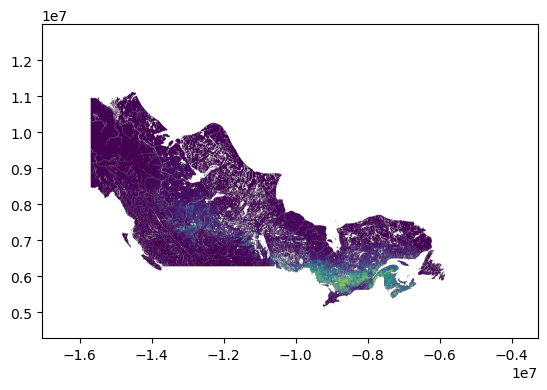

<Axes: >

In [27]:
show(rasterio.open(data))